# 3.2.1 DSSM 双塔召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

怎样把用户与物品分别编码，使物品向量可以离线建索引，同时仍能从全库找回相关候选？

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [Huang et al., 2013, DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 怎样把用户与物品分别编码，使物品向量可以离线建索引，同时仍能从全库找回相关候选？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

DSSM 最初面向搜索点击，把 query 与 document 映射到同一语义空间。推荐系统继承的是“两侧独立编码 + 相似度学习”这一可检索结构。双塔牺牲候选前的深交互，换取 item embedding 可预计算和 ANN 检索。

**来源：** [Huang et al., 2013, DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Math by Hand

用户塔输出 $u=f_\theta(x_u)\in\mathbb R^d$，物品塔输出 $v=g_\phi(x_i)\in\mathbb R^d$。归一化后，$s(u,i)=u^\top v$ 就是余弦相似度。形状是用户批次 $[B,d]$ 乘物品库 $[N,d]^\top$，得到 $[B,N]$ 分数。线上只算一次用户向量，再从索引找 Top-K。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

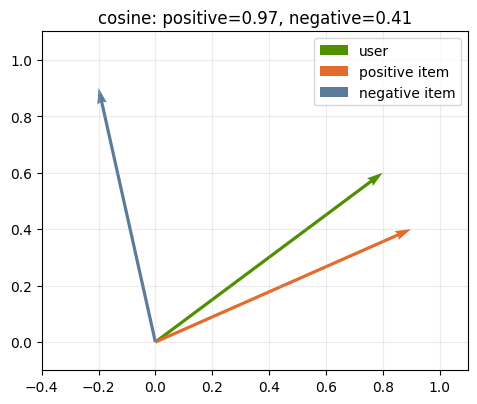

{'user@positive': np.float64(0.975), 'user@negative': np.float64(0.412)}


In [2]:
import numpy as np, matplotlib.pyplot as plt
user=np.array([.8,.6]); positive=np.array([.9,.4]); negative=np.array([-.2,.9])
norm=lambda x:x/np.linalg.norm(x)
scores=[norm(user)@norm(v) for v in [positive,negative]]
fig,ax=plt.subplots(figsize=(5.5,4.4))
for vector,label,color in [(user,'user','#4f8f00'),(positive,'positive item','#e36b2c'),(negative,'negative item','#5b7c99')]:
    ax.quiver(0,0,*vector,angles='xy',scale_units='xy',scale=1,label=label,color=color)
ax.set(xlim=(-.4,1.1),ylim=(-.1,1.1),title=f'cosine: positive={scores[0]:.2f}, negative={scores[1]:.2f}')
ax.grid(alpha=.25); ax.legend(); plt.show()
print({'user@positive':round(scores[0],3),'user@negative':round(scores[1],3)})

## Data

GroupLens MovieLens latest-small 真实评分。用户/物品 ID 来自原始日志，`rating>=4` 作为正反馈，并按真实时间戳留出测试行为。

**防泄漏清单：**按时间切分；词表只由训练期建立；负样本来自已观察低评分；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.matching.DSSM。full profile 映射 TorchEasyRec 双塔配置，并把 item tower 导出到 Faiss、HNSW 或 Milvus。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_dssm, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_dssm))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_dssm(epochs: int = 24) -> dict:
    seed_everything(); ratings, _, provenance = _real_ratings()
    events = ratings.sort_values("timestamp").tail(5200).reset_index(drop=True)
    split = int(len(events) * .8)
    train, test = events.iloc[:split], events.iloc[split:]
    n_users, n_items = ratings.user_id.nunique(), ratings.item_id.nunique()
    user_features = [SparseFeature("user_id", n_users + 1, 16, padding_idx=0)]
    item_features = [SparseFeature("item_id", n_items + 1, 16, padding_idx=0)]
    tower = {"dims": [32, 16], "activation": "relu", "dropout": 0.0}
    model = DSSM(user_features, item_features, tower, tower, temperature=.12)

    def fields(frame):
        return {
            "user_id": torch.tensor(frame.user_id.to_numpy() + 1, dtype=torch.long),
            "item_id": torch.tensor(frame.item_id.to_numpy() + 1, dtype=torch.long),
        }

    losses = _train_binary(model, fields(train), torch.tensor(train.like.to_numpy()), epochs, .

## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_dssm()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.matching.DSSM', 'dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 20241, 'users_used': 96, 'items_used': 480, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0, 'train_rows': 4160, 'test_rows': 1040, 'label': 'observed rating >= 4.0'}}
inference contract: 用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。
loss: 0.7076 → 0.6251


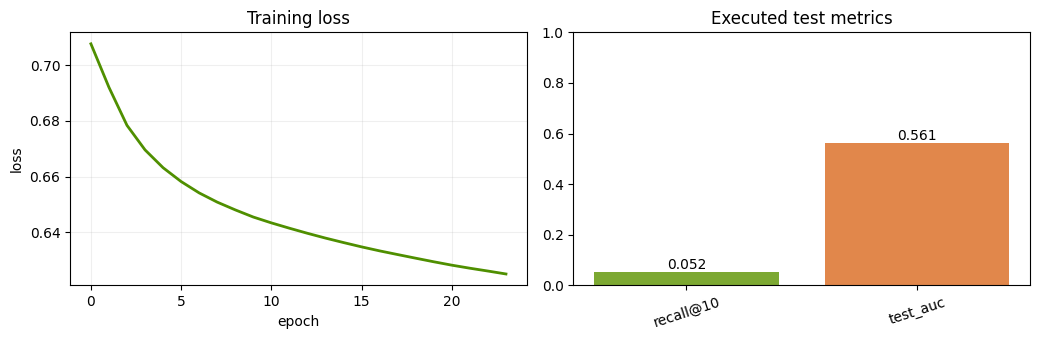

,value
recall@10,0.052083
test_auc,0.561013


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'recall@10': result['recall@10'], 'test_auc': result['test_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 recall@10 = **{result['recall@10']:.4f}**。
- 辅助指标 test_auc = **{result['test_auc']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MovieLens 是显式评分而非曝光点击，离线 Recall 只能验证真实行为上的训练—索引—检索链路，不代表生产长尾目录收益。

### 工业边界

用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 recall@10 = **0.0521**。
- 辅助指标 test_auc = **0.5610**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **0.7076** 降到 **0.6251**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MovieLens 是显式评分而非曝光点击，离线 Recall 只能验证真实行为上的训练—索引—检索链路，不代表生产长尾目录收益。

### 工业边界

用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'DSSM 双塔召回',
    'primary_metric': 'recall@10', 'primary_value': float(result['recall@10']),
    'secondary_metric': 'test_auc', 'secondary_value': float(result['test_auc']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '3_2_1_dssm',
    'dataset': 'MovieLens latest-small',
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_2','3_2_1_dssm',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_2/3_2_1_dssm.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['recall@10']) <= 1
assert np.isfinite(float(result['test_auc']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。